In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
 

In [20]:
df = pd.read_csv('SOCR-HeightWeight.csv')

Text(0, 0.5, 'weight')

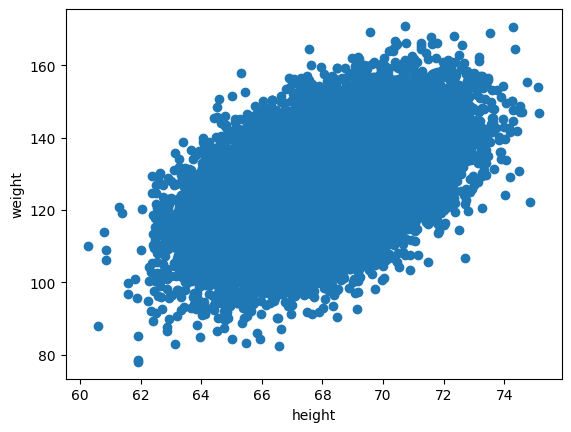

In [21]:
plt.scatter(df['Height(Inches)'],df['Weight(Pounds)'])
plt.xlabel("height")
plt.ylabel("weight")

In [22]:
## our main aim to create a best fit line
x=df[['Weight(Pounds)']]
y=df['Height(Inches)']
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=42)

In [23]:
from sklearn.linear_model import LinearRegression
regression = LinearRegression()


In [24]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [27]:
x_train = scaler.fit_transform(x_train)

In [28]:
x_train

array([[ 0.08310666],
       [-0.99311816],
       [ 0.50040551],
       ...,
       [-0.52354516],
       [ 0.73759547],
       [-0.36861454]], shape=(18750, 1))

In [29]:
x_test  =scaler.transform(x_test)

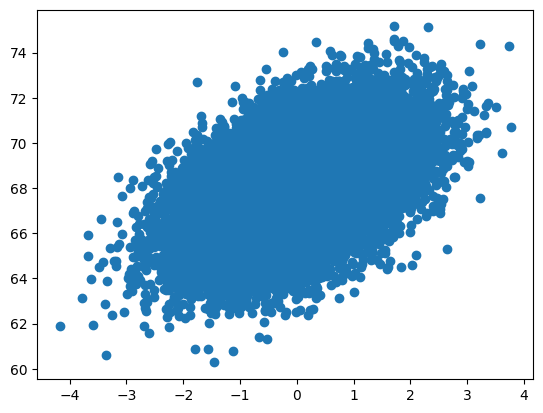

In [33]:
plt.scatter(x_train,y_train)


In [34]:
##Train the simple Linerar Model
from sklearn.linear_model import LinearRegression
regression = LinearRegression()
regression.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


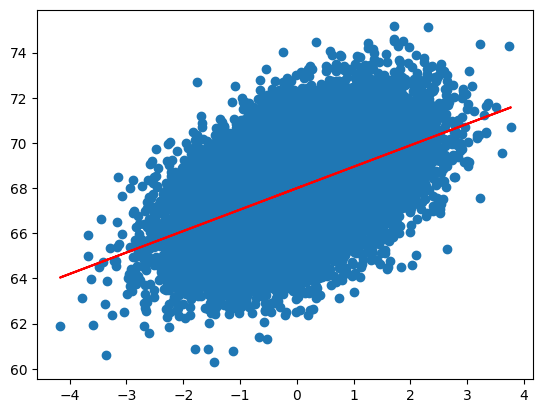

In [37]:
plt.scatter(x_train,y_train)
plt.plot(x_train,regression.predict(x_train),color ="r")

In [38]:
y_pred_test = regression.predict(x_test)


In [40]:
y_pred_test,y_test

(array([68.58261344, 66.76157097, 68.7214503 , ..., 68.69540615,
        66.88567232, 67.99616317], shape=(6250,)),
 6868     68.42447
 24016    67.89663
 9668     67.65922
 13640    69.01299
 14018    69.01055
            ...   
 24717    63.76497
 2578     69.34872
 10121    69.24622
 21601    64.57820
 3474     63.55149
 Name: Height(Inches), Length: 6250, dtype: float64)

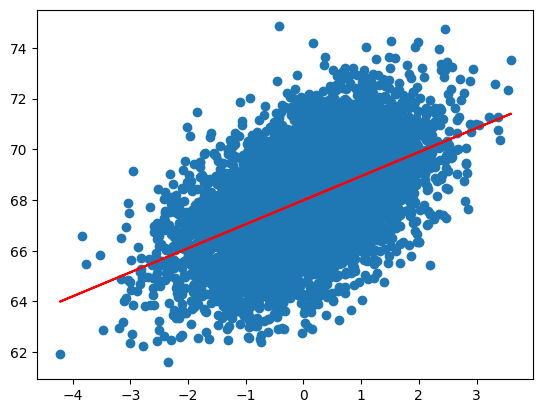

In [41]:
plt.scatter(x_test,y_test)
plt.plot(x_test,regression.predict(x_test),color ="r")

In [ ]:
from sklearn.metrics import r2_score ,mean_absolute_error,mean_squared_error,root_mean_squared_error
score = r2_score(y_test,y_pred_test)
mae = mean_absolute_error(y_test,y_pred_test)
mse =mean_squared_error(y_test,y_pred_test)
rmse = root_mean_squared_error(y_test,y_pred_test)
print(mae)
print(mse)
print(rmse)
print(score)

1.3166150322297803
2.7333807993730996
1.6532939240719116
0.2592643941428425


In [45]:
regression

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [46]:
## I geeted new data points
scaled_weight = scaler.transform([[80]])

c:\Users\visha\OneDrive\Desktop\varun\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [50]:
print(regression.predict([scaled_weight[0]]))

[64.15335388]


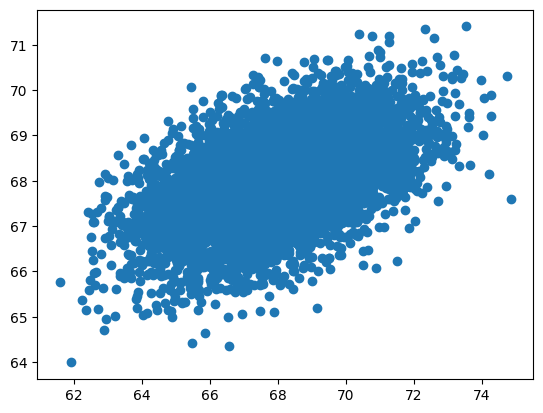

In [51]:
##ASUMPTIONS
plt.scatter(y_test,y_pred_test)


In [52]:
##residual 
residual = y_test - y_pred_test
residual

6868    -0.158143
24016    1.135059
9668    -1.062230
13640    1.075385
14018    3.210589
           ...   
24717   -2.430532
2578    -0.365345
10121    0.550814
21601   -2.307472
3474    -4.444673
Name: Height(Inches), Length: 6250, dtype: float64

C:\Users\visha\AppData\Local\Temp\ipykernel_51932\1648558248.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residual,kde= True)


<Axes: xlabel='Height(Inches)', ylabel='Density'>

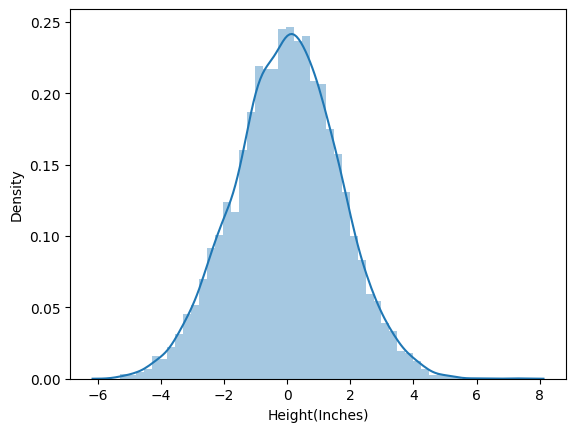

In [53]:
##plot this residual
sns.distplot(residual,kde= True)